In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")

In [3]:
trades.head()

trades.info()

trades.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [4]:
sentiment.head()

sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
trades["date"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms"
).dt.date

In [7]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

In [8]:
df = trades.merge(
    sentiment,
    on="date",
    how="left"
)

In [9]:
df.shape

df["classification"].value_counts()

,count
classification,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


In [11]:
df["Closed PnL"] = pd.to_numeric(
    df["Closed PnL"],
    errors="coerce"
)

df["win"] = (
    df["Closed PnL"] > 0
).astype(int)

In [13]:
sentiment_stats = (
    df.groupby("classification")
      .agg(
          trades=("Closed PnL","count"),
          avg_pnl=("Closed PnL","mean"),
          total_pnl=("Closed PnL","sum"),
          win_rate=("win","mean")
      )
      .reset_index()
)

sentiment_stats

,classification,trades,avg_pnl,total_pnl,win_rate
0,Extreme Greed,6962,25.418772,1.769655e+05,0.490089
1,Fear,133871,50.047622,6.699925e+06,0.415146
2,Greed,36289,87.894859,3.189617e+06,0.446471
3,Neutral,7141,22.229713,1.587424e+05,0.317182


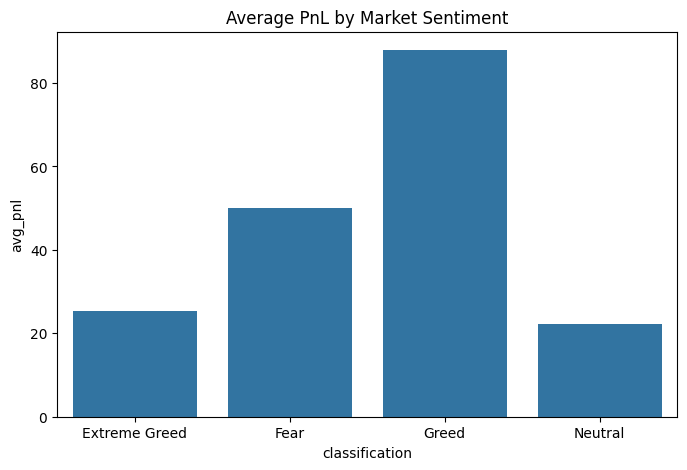

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_stats,
    x="classification",
    y="avg_pnl"
)

plt.title("Average PnL by Market Sentiment")
plt.show()

In [16]:
top_traders = (
    df.groupby("Account")
      .agg(
          total_pnl=("Closed PnL","sum"),
          trades=("Closed PnL","count"),
          avg_pnl=("Closed PnL","mean"),
          win_rate=("win","mean")
      )
      .reset_index()
      .sort_values("total_pnl", ascending=False)
)

<Figure size 1200x600 with 0 Axes>

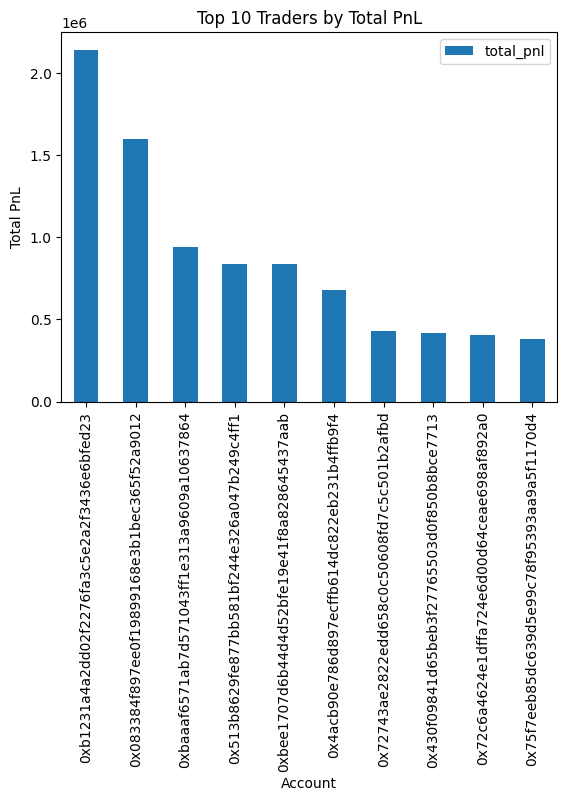

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

top_traders.head(10).plot(
    x="Account",
    y="total_pnl",
    kind="bar"
)

plt.title("Top 10 Traders by Total PnL")
plt.ylabel("Total PnL")
plt.show()

In [19]:
top_accounts = top_traders.head(10)["Account"]

top_sentiment = (
    df[df["Account"].isin(top_accounts)]
      .groupby(["Account","classification"])
      ["Closed PnL"]
      .sum()
      .reset_index()
)

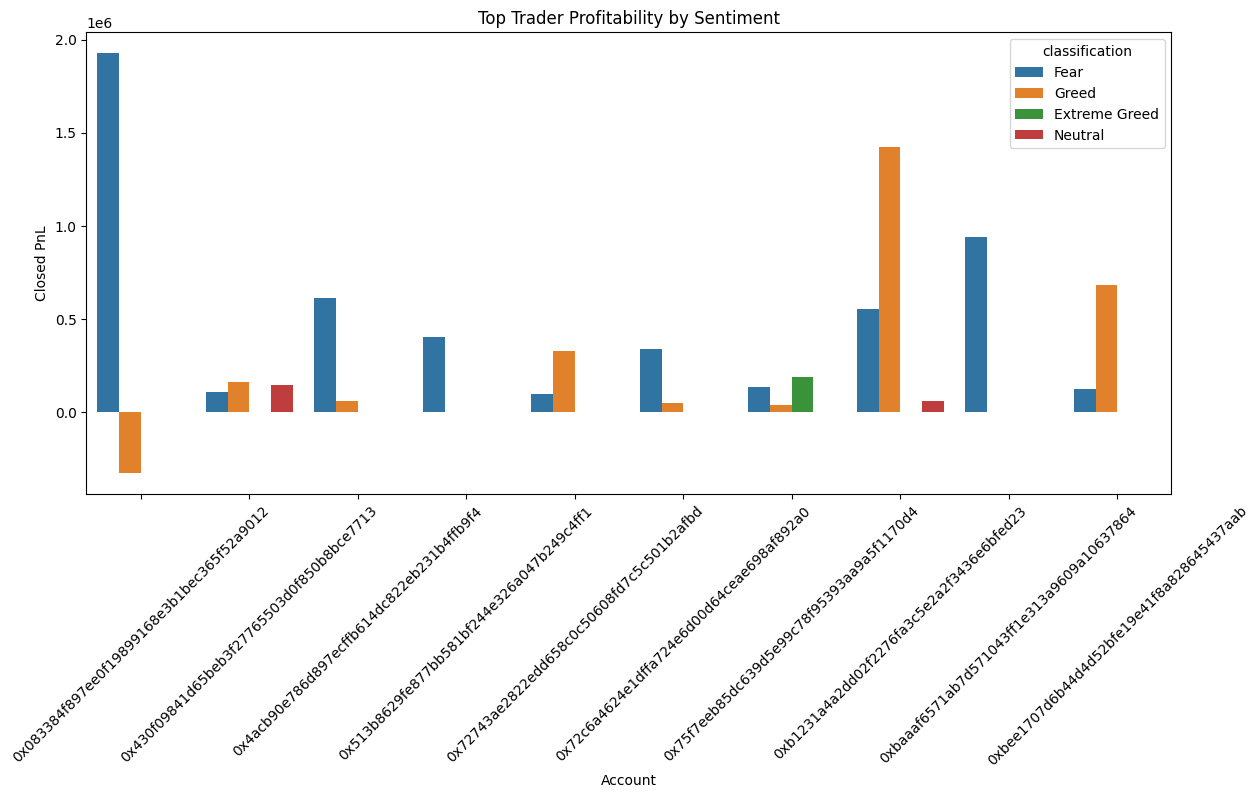

In [20]:
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_sentiment,
    x="Account",
    y="Closed PnL",
    hue="classification"
)

plt.xticks(rotation=45)
plt.title("Top Trader Profitability by Sentiment")
plt.show()

In [22]:
direction_stats = (
    df.groupby(["classification", "Side"])
      .agg(
          avg_pnl=("Closed PnL", "mean"),
          total_pnl=("Closed PnL", "sum"),
          win_rate=("win", "mean")
      )
      .reset_index()
)

direction_stats

,classification,Side,avg_pnl,total_pnl,win_rate
0,Extreme Greed,BUY,25.578564,8.622534e+04,0.456838
1,Extreme Greed,SELL,25.268770,9.074015e+04,0.521303
2,Fear,BUY,58.074630,3.837630e+06,0.261043
3,Fear,SELL,42.222976,2.862296e+06,0.565364
4,Greed,BUY,12.489506,1.926007e+05,0.220738
5,Greed,SELL,143.617782,2.997016e+06,0.613283
6,Neutral,BUY,15.646108,5.483961e+04,0.390585
7,Neutral,SELL,28.576120,1.039028e+05,0.246425


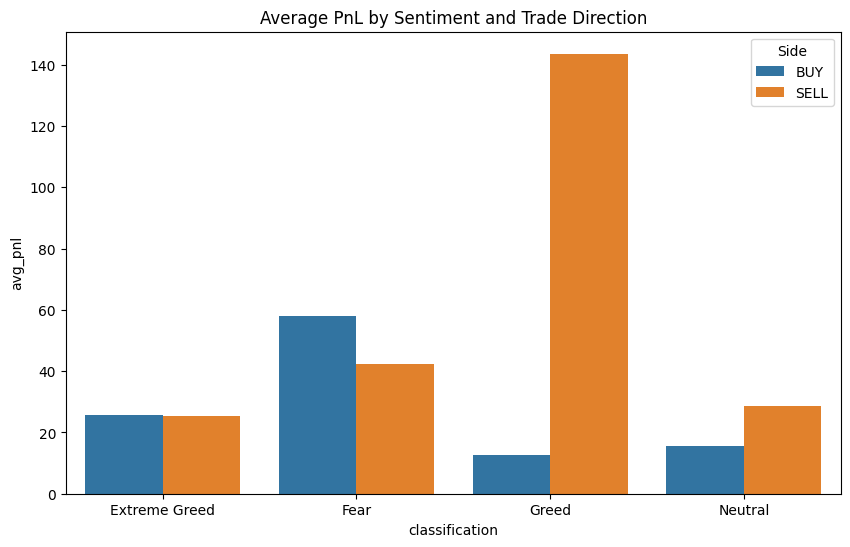

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=direction_stats,
    x="classification",
    y="avg_pnl",
    hue="Side"
)

plt.title("Average PnL by Sentiment and Trade Direction")
plt.show()

In [28]:
df["size_group"] = pd.qcut(
    df["Size USD"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Whale"
    ]
)

In [29]:
size_stats = (
    df.groupby("size_group")
      .agg(
          trades=("Closed PnL","count"),
          avg_pnl=("Closed PnL","mean"),
          total_pnl=("Closed PnL","sum"),
          win_rate=("win","mean")
      )
      .reset_index()
)

size_stats

/tmp/ipykernel_3876/1594969643.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("size_group")


,size_group,trades,avg_pnl,total_pnl,win_rate
0,Small,52829,2.168210,1.145443e+05,0.431108
1,Medium,52783,6.596610,3.481889e+05,0.383211
2,Large,52806,22.015666,1.162559e+06,0.426845
3,Whale,52806,164.217447,8.671666e+06,0.403875


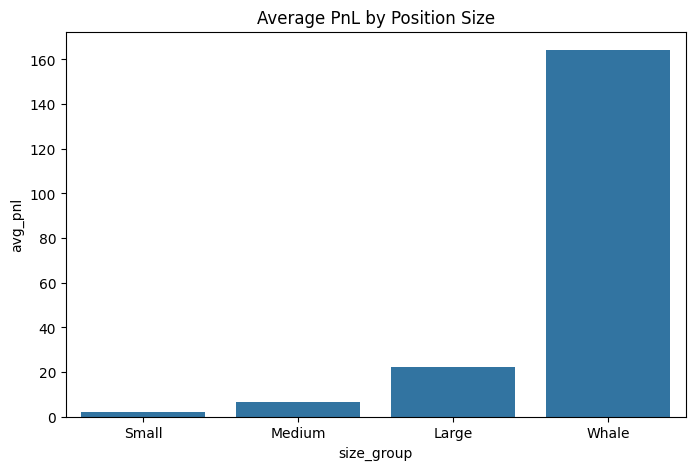

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=size_stats,
    x="size_group",
    y="avg_pnl"
)

plt.title("Average PnL by Position Size")
plt.show()

In [31]:
mapping = {
    "Fear": 1,
    "Neutral": 2,
    "Greed": 3,
    "Extreme Greed": 4
}

df["sentiment_score"] = (
    df["classification"]
      .map(mapping)
)

In [32]:
df[
    ["sentiment_score","Closed PnL"]
].corr()

,sentiment_score,Closed PnL
sentiment_score,1.000000,0.009227
Closed PnL,0.009227,1.000000


In [34]:
daily_stats = (
    df.groupby("date")
      .agg(
          daily_pnl=("Closed PnL","sum"),
          trades=("Closed PnL","count")
      )
      .reset_index()
)

In [35]:
daily_stats = daily_stats.merge(
    sentiment[["date","value"]],
    on="date",
    how="left"
)

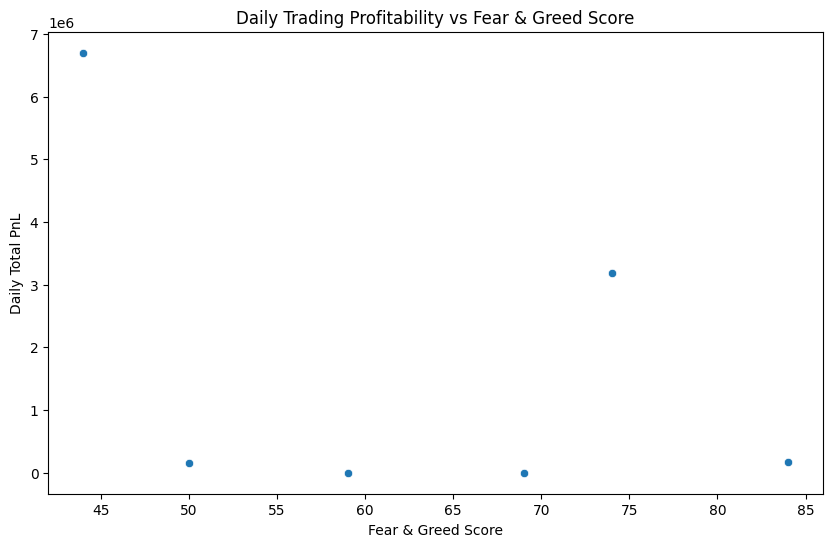

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=daily_stats,
    x="value",
    y="daily_pnl"
)

plt.title(
    "Daily Trading Profitability vs Fear & Greed Score"
)

plt.xlabel("Fear & Greed Score")
plt.ylabel("Daily Total PnL")

plt.show()

In [37]:
trader_stats = (
    df.groupby("Account")
      .agg(
          trades=("Closed PnL","count"),
          total_pnl=("Closed PnL","sum"),
          avg_pnl=("Closed PnL","mean"),
          win_rate=("win","mean")
      )
      .reset_index()
)

In [38]:
consistent_traders = trader_stats[
    trader_stats["trades"] > 1000
].sort_values(
    "win_rate",
    ascending=False
)

consistent_traders.head(10)

,Account,trades,total_pnl,avg_pnl,win_rate
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,379095.406711,38.319560,0.810876
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,168658.004994,52.071011,0.519914
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,677747.050643,155.589314,0.486226
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,416541.872341,336.735548,0.484236
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,940163.806220,44.364091,0.467582
18,0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,1559,14900.443047,9.557693,0.452213
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,47885.320514,6.577654,0.442720
28,0xb899e522b5715391ae1d4f137653e7906c5e2115,4838,22488.500821,4.648305,0.438611
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,132464.814554,9.951530,0.438585
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,836080.553077,20.806305,0.428230


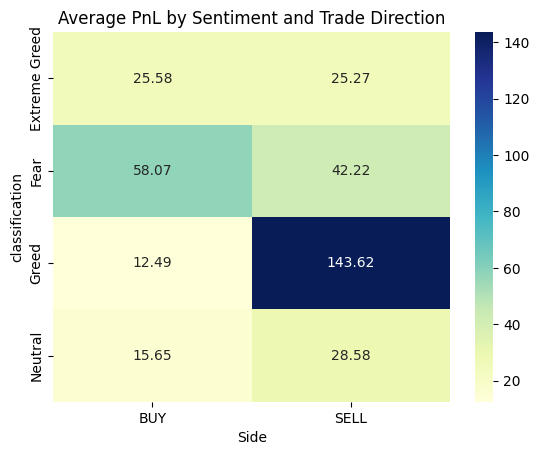

In [39]:
pivot = pd.pivot_table(
    df,
    values="Closed PnL",
    index="classification",
    columns="Side",
    aggfunc="mean"
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average PnL by Sentiment and Trade Direction")
plt.show()